# Voting Regressor — Ensemble Learning

## Overview

A **Voting Regressor** is an ensemble method that combines multiple regression models and averages their predictions to produce a final output. The core intuition is that a group of diverse, imperfect models can collectively outperform any single model by cancelling out individual errors.

### How It Works

Given $n$ base estimators $f_1, f_2, \ldots, f_n$, the Voting Regressor predicts:

$$\hat{y} = \frac{1}{n} \sum_{i=1}^{n} f_i(x)$$

When weights are assigned:

$$\hat{y} = \frac{\sum_{i=1}^{n} w_i \cdot f_i(x)}{\sum_{i=1}^{n} w_i}$$

### Why Use It?

- Reduces variance compared to individual high-variance models (e.g., Decision Trees)
- Reduces bias compared to individual high-bias models (e.g., shallow regressors)
- Works well when base models are diverse and make different types of errors
- Simple to implement with no complex hyperparameter tuning


### Imports

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42

### Dataset — California Housing

We use the **California Housing** dataset from scikit-learn. It contains information about housing districts in California derived from the 1990 census.

| Feature | Description |
|---|---|
| `MedInc` | Median income in block group |
| `HouseAge` | Median house age in block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Block group population |
| `AveOccup` | Average number of household members |
| `Latitude` | Block group latitude |
| `Longitude` | Block group longitude |
| `MedHouseVal` | **Target** — Median house value (in $100,000s) |

In [5]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=[
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude'
])
df['MedHouseVal'] = data.target
df.head(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [6]:
print(f"Shape: {df.shape}")
print(f"\nTarget statistics:")
print(df['MedHouseVal'].describe().round(3))

Shape: (20640, 9)

Target statistics:
count    20640.000
mean         2.069
std          1.154
min          0.150
25%          1.196
50%          1.797
75%          2.647
max          5.000
Name: MedHouseVal, dtype: float64


### Target Distribution

Understanding the distribution of the target variable helps us interpret model performance. A heavily skewed target may require transformation.

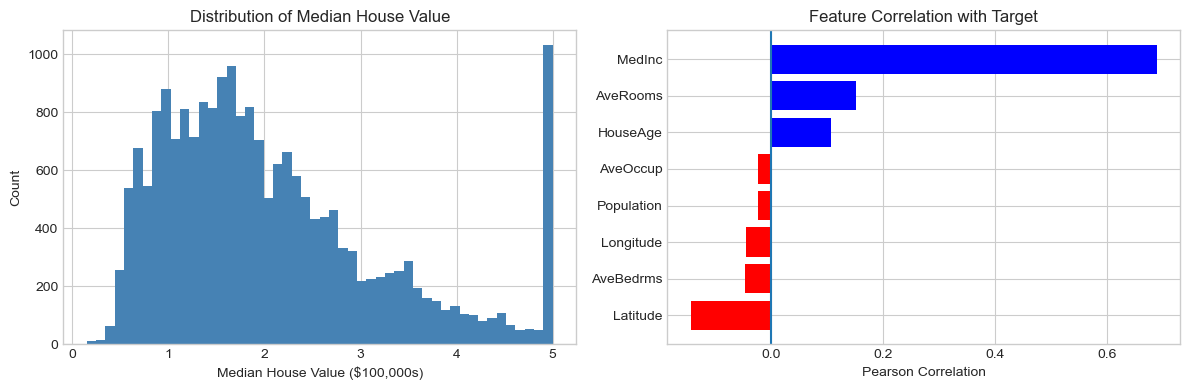

In [68]:
plt.figure(figsize=(12,4))

# Histogram
plt.subplot(1,2,1)
plt.hist(df['MedHouseVal'], bins=50, color='steelblue')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')

# Correlation with target
corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['red' if v < 0 else 'blue' for v in corr.values]

plt.subplot(1,2,2)
plt.barh(corr.index, corr.values, color=colors)
plt.title('Feature Correlation with Target')
plt.xlabel('Pearson Correlation')
plt.axvline(0)

plt.tight_layout()
plt.show()

**Observations:**
- The target is right-skewed, with a spike at 5.0 (values were capped at $500,000 in the original data).
- `MedInc` has the strongest positive correlation with house value, which is expected.
- `Latitude` and `Longitude` show moderate negative correlations, reflecting California's geography (higher-value properties near the coast).

### Feature and Target Split

In [63]:
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (20640, 8)
Target shape   : (20640,)


### Part I — Mixed Estimators (LR + DT + KNN)

###  Define Base Models

Choose three fundamentally different algorithms as base estimators:

- **Linear Regression (LR):** Assumes a linear relationship between features and target. Low variance, potentially high bias.
- **Decision Tree Regressor (DT):** Partitions the feature space into rectangular regions. Low bias but high variance — prone to overfitting.
- **K-Nearest Neighbors (KNN):** Predicts based on the average of nearby training samples. Non-parametric, sensitive to feature scale and local structure.

Diversity among base models is key — models that make different errors benefit most from averaging.

In [13]:
lr  = LinearRegression()
dt  = DecisionTreeRegressor(random_state=SEED)
knn = KNeighborsRegressor()

estimators = [('lr', lr), ('dt', dt), ('knn', knn)]

### Cross-Validation of Individual Models

We evaluate each model independently using 10-fold cross-validation and the R² metric.

**R² (coefficient of determination)** measures the proportion of variance in the target explained by the model:
- R² = 1.0 → perfect predictions
- R² = 0.0 → model performs no better than predicting the mean
- R² < 0.0 → model performs worse than predicting the mean

In [15]:
individual_scores = {}

for name, estimator in estimators:
    scores = cross_val_score(estimator, X, y, scoring='r2', cv=10)
    individual_scores[name] = np.round(np.mean(scores), 4)
    print(f"{name:>6}  R2 = {individual_scores[name]:.2f}  (std = {scores.std():.3f})")

    lr  R2 = 0.51  (std = 0.059)
    dt  R2 = 0.25  (std = 0.231)
   knn  R2 = -0.14  (std = 0.307)


### Voting Regressor (Equal Weights)

In [17]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr, X, y, scoring='r2', cv=10)
vr_score = np.round(np.mean(scores), 4)
print(f"Voting Regressor  R2 = {vr_score:.2f}  (std = {scores.std():.3f})")

Voting Regressor  R2 = 0.48  (std = 0.095)


### Visualization — Individual vs. Ensemble

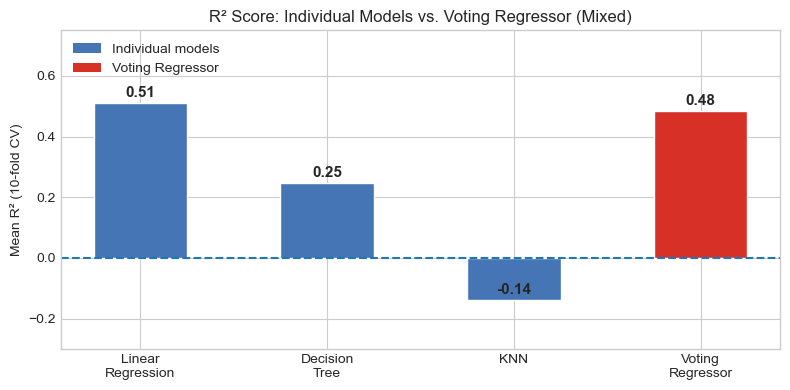

In [77]:
all_scores = {**individual_scores, 'VotingRegressor': vr_score}
colors = ['#4575b4', '#4575b4', '#4575b4', '#d73027']

plt.figure(figsize=(8,4))

bars = plt.bar(all_scores.keys(), all_scores.values(),
               color=colors, width=0.5, edgecolor='white')

# Value labels
for bar, val in zip(bars, all_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.2f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.ylim(-0.3, 0.75)
plt.axhline(0, linestyle='--')

plt.title('R² Score: Individual Models vs. Voting Regressor (Mixed)')
plt.ylabel('Mean R² (10-fold CV)')
plt.xticks(range(len(all_scores)),
           ['Linear\nRegression', 'Decision\nTree', 'KNN', 'Voting\nRegressor'])

# Legend
legend_elements = [
    Patch(facecolor='#4575b4', label='Individual models'),
    Patch(facecolor='#d73027', label='Voting Regressor')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


**Note:** The Voting Regressor scores between LR and DT, showing that the poor KNN score drags the ensemble down. This motivates exploring weighted voting.

### Weighted Voting — Grid Search Over Weights

By assigning different weights to each base model, we can reduce the influence of weaker models and amplify the stronger ones.

We perform a brute-force grid search over weight combinations `[1, 2, 3]` for each of the three estimators (LR, DT, KNN).

In [22]:
weight_results = []

for i in range(1, 4):
    for j in range(1, 4):
        for k in range(1, 4):
            vr_w = VotingRegressor(estimators, weights=[i, j, k])
            scores = cross_val_score(vr_w, X, y, scoring='r2', cv=10)
            r2 = np.round(np.mean(scores), 4)
            weight_results.append({'lr_w': i, 'dt_w': j, 'knn_w': k, 'r2': r2})
            print(f"LR={i}, DT={j}, KNN={k}  -->  R2 = {r2:.2f}")

results_df = pd.DataFrame(weight_results)

LR=1, DT=1, KNN=1  -->  R2 = 0.48
LR=1, DT=1, KNN=2  -->  R2 = 0.39
LR=1, DT=1, KNN=3  -->  R2 = 0.32
LR=1, DT=2, KNN=1  -->  R2 = 0.48
LR=1, DT=2, KNN=2  -->  R2 = 0.44
LR=1, DT=2, KNN=3  -->  R2 = 0.38
LR=1, DT=3, KNN=1  -->  R2 = 0.47
LR=1, DT=3, KNN=2  -->  R2 = 0.45
LR=1, DT=3, KNN=3  -->  R2 = 0.41
LR=2, DT=1, KNN=1  -->  R2 = 0.52
LR=2, DT=1, KNN=2  -->  R2 = 0.45
LR=2, DT=1, KNN=3  -->  R2 = 0.39
LR=2, DT=2, KNN=1  -->  R2 = 0.53
LR=2, DT=2, KNN=2  -->  R2 = 0.48
LR=2, DT=2, KNN=3  -->  R2 = 0.44
LR=2, DT=3, KNN=1  -->  R2 = 0.51
LR=2, DT=3, KNN=2  -->  R2 = 0.49
LR=2, DT=3, KNN=3  -->  R2 = 0.46
LR=3, DT=1, KNN=1  -->  R2 = 0.53
LR=3, DT=1, KNN=2  -->  R2 = 0.48
LR=3, DT=1, KNN=3  -->  R2 = 0.43
LR=3, DT=2, KNN=1  -->  R2 = 0.54
LR=3, DT=2, KNN=2  -->  R2 = 0.51
LR=3, DT=2, KNN=3  -->  R2 = 0.47
LR=3, DT=3, KNN=1  -->  R2 = 0.54
LR=3, DT=3, KNN=2  -->  R2 = 0.51
LR=3, DT=3, KNN=3  -->  R2 = 0.48


In [23]:
best = results_df.loc[results_df['r2'].idxmax()]
print("Best configuration:")
print(f"  LR weight  : {int(best.lr_w)}")
print(f"  DT weight  : {int(best.dt_w)}")
print(f"  KNN weight : {int(best.knn_w)}")
print(f"  R2 score   : {best.r2:.2f}")

Best configuration:
  LR weight  : 3
  DT weight  : 2
  KNN weight : 1
  R2 score   : 0.54


### Heatmap — Effect of LR and DT Weights (KNN fixed at best value)

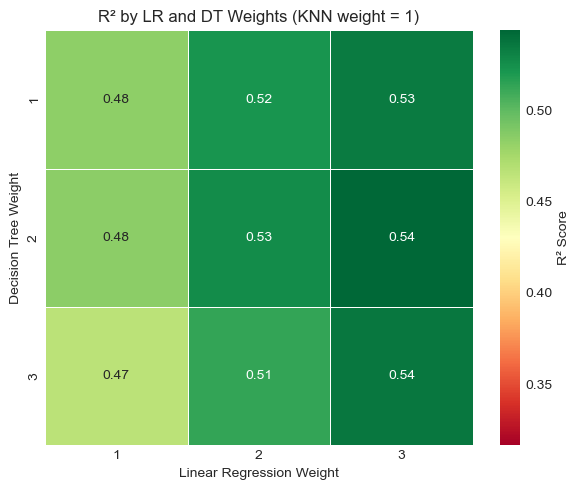

In [87]:
best_knn_w = int(best.knn_w)

pivot_data = results_df[results_df['knn_w'] == best_knn_w].pivot(
    index='dt_w', columns='lr_w', values='r2'
)

plt.figure(figsize=(6,5))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    vmin=results_df['r2'].min(),
    vmax=results_df['r2'].max(),
    cbar_kws={'label': 'R² Score'}
)

plt.title(f'R² by LR and DT Weights (KNN weight = {best_knn_w})')
plt.xlabel('Linear Regression Weight')
plt.ylabel('Decision Tree Weight')

plt.tight_layout()
plt.show()

**Interpretation:** Higher weights on Linear Regression consistently improve performance, which aligns with LR having the strongest individual R² among the three models. The KNN model hurts performance when over-weighted — assigning it the lowest weight gives the best results.

### Part II — Same Algorithm, Different Complexity (Decision Trees)

Voting Regressors are not limited to mixing different algorithms. You can also ensemble multiple instances of the **same algorithm** with different hyperparameters. Here we use Decision Trees with varying `max_depth` to create models of increasing complexity.

| Model | `max_depth` | Behavior |
|---|---|---|
| `dt1` | 1 | Very shallow — high bias, low variance |
| `dt2` | 3 | Moderate depth |
| `dt3` | 5 | Moderate depth |
| `dt4` | 7 | Deep — lower bias, higher variance |
| `dt5` | None | Fully grown — low bias, very high variance |

In [28]:
dt1 = DecisionTreeRegressor(max_depth=1,    random_state=SEED)
dt2 = DecisionTreeRegressor(max_depth=3,    random_state=SEED)
dt3 = DecisionTreeRegressor(max_depth=5,    random_state=SEED)
dt4 = DecisionTreeRegressor(max_depth=7,    random_state=SEED)
dt5 = DecisionTreeRegressor(max_depth=None, random_state=SEED)

dt_estimators = [('dt1', dt1), ('dt2', dt2), ('dt3', dt3), ('dt4', dt4), ('dt5', dt5)]

### Cross-Validation — Individual Trees

In [30]:
dt_individual_scores = {}
dt_individual_std = {}

for name, estimator in dt_estimators:
    scores = cross_val_score(estimator, X, y, scoring='r2', cv=10)
    dt_individual_scores[name] = np.round(np.mean(scores), 4)
    dt_individual_std[name] = np.round(np.std(scores), 4)
    print(f"{name}  R2 = {dt_individual_scores[name]:.2f}  (std = {dt_individual_std[name]:.3f})")

dt1  R2 = 0.13  (std = 0.218)
dt2  R2 = 0.36  (std = 0.205)
dt3  R2 = 0.43  (std = 0.202)
dt4  R2 = 0.47  (std = 0.136)
dt5  R2 = 0.25  (std = 0.231)


### Voting Regressor — Decision Trees Ensemble

In [32]:
vr_dt = VotingRegressor(dt_estimators)
scores = cross_val_score(vr_dt, X, y, scoring='r2', cv=10)
vr_dt_score = np.round(np.mean(scores), 4)
vr_dt_std = np.round(np.std(scores), 4)
print(f"Voting Regressor (DT ensemble)  R2 = {vr_dt_score:.2f}  (std = {vr_dt_std:.3f})")

Voting Regressor (DT ensemble)  R2 = 0.50  (std = 0.144)


### Visualization — Depth vs. R² (Bias-Variance Trade-off)

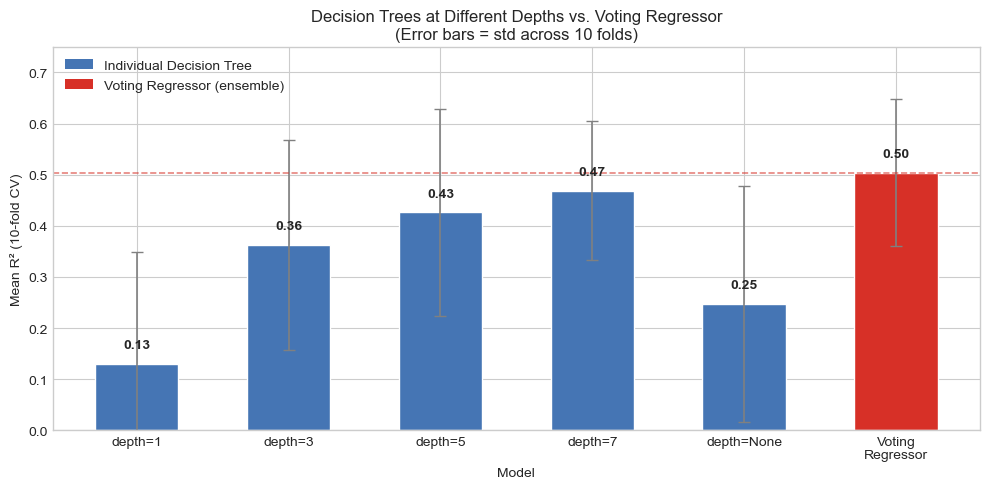

In [92]:
labels = ['depth=1', 'depth=3', 'depth=5', 'depth=7', 'depth=None', 'Voting\nRegressor']
scores_list = list(dt_individual_scores.values()) + [vr_dt_score]
std_list = list(dt_individual_std.values()) + [vr_dt_std]
bar_colors = ['#4575b4'] * 5 + ['#d73027']

plt.figure(figsize=(10,5))
bars = plt.bar(labels,scores_list,color=bar_colors,width=0.55,yerr=std_list,capsize=4,error_kw={'elinewidth':1.2, 'ecolor':'gray'},edgecolor='white')

# Value labels
for bar, val in zip(bars, scores_list):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025, f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold' )

plt.ylim(0, 0.75)
plt.axhline(vr_dt_score, color='#d73027', linestyle='--', linewidth=1.2, alpha=0.6)
plt.title('Decision Trees at Different Depths vs. Voting Regressor\n(Error bars = std across 10 folds)')
plt.ylabel('Mean R² (10-fold CV)')
plt.xlabel('Model')

# Legend
legend_elements = [Patch(facecolor='#4575b4', label='Individual Decision Tree'),Patch(facecolor='#d73027', label='Voting Regressor (ensemble)')]
plt.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

**Key observations:**
- Very shallow trees (depth=1) underfits — high bias.
- Fully grown trees (depth=None) overfit — high variance, as shown by lower CV score.
- The Voting Regressor (R² = 0.50) **outperforms every individual tree**, including the best single tree (depth=7, R² = 0.47).
- The ensemble also tends to have a lower standard deviation across folds, indicating more stable predictions.

### Prediction Scatter Plot — Actual vs. Predicted

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Fit and predict with the DT ensemble voting regressor
vr_dt.fit(X_train, y_train)
y_pred = vr_dt.predict(X_test)

r2_test = r2_score(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test R²   : {r2_test:.4f}")
print(f"Test RMSE : {rmse_test:.4f}  (in $100,000 units)")
print(f"Test RMSE : ${rmse_test * 100_000:,.0f}")

Test R²   : 0.6621
Test RMSE : 0.6654  (in $100,000 units)
Test RMSE : $66,540


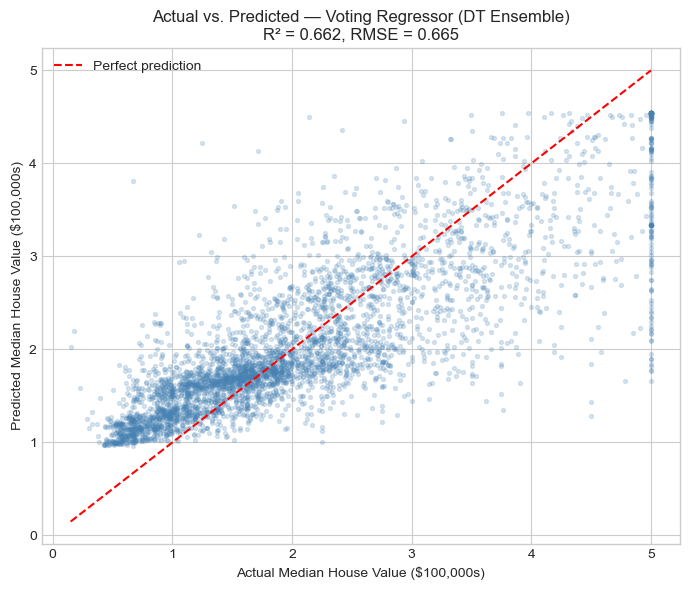

In [95]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred, alpha=0.2, s=8, color='steelblue')

# Perfect prediction line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual Median House Value ($100,000s)')
plt.ylabel('Predicted Median House Value ($100,000s)')
plt.title(f'Actual vs. Predicted — Voting Regressor (DT Ensemble)\nR² = {r2_test:.3f}, RMSE = {rmse_test:.3f}')

plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()


| Model | R² (CV) | Notes |
|---|---|---|
| Linear Regression | 0.51 | Strongest individual model |
| Decision Tree | 0.24 | Unstable, high variance |
| KNN | -0.14 | Poorly suited here without feature scaling |
| Voting Regressor (equal weights) | 0.48 | Dragged down by KNN |
| Voting Regressor (best weights) | ~0.54 | Weighted: LR > DT > KNN |
| DT Ensemble (depth=7, best) | 0.47 | Best single tree |
| Voting Regressor (DT ensemble) | 0.50 | Outperforms all individual trees |

